In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sb

import plotly as py
import plotly.graph_objs as go

from sklearn.cluster import KMeans

from warnings import filterwarnings as fw
fw("ignore")

In [3]:
df = pd.read_csv('customers.csv',index_col=0,sep=',')

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
CustomerID,,,,,
1,Male,19,15,39,4
2,Male,21,15,81,3
3,Female,20,16,6,4
4,Female,23,16,77,3
5,Female,31,17,40,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
 4   cluster                 200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100),cluster
count,200.000000,200.000000,200.000000,200.00000
mean,38.850000,60.560000,50.200000,2.24500
std,13.969007,26.264721,25.823522,1.81423
min,18.000000,15.000000,1.000000,0.00000
25%,28.750000,41.500000,34.750000,1.00000
50%,36.000000,61.500000,50.000000,2.00000
75%,49.000000,78.000000,73.000000,4.00000
max,70.000000,137.000000,99.000000,5.00000


In [6]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
cluster                   0
dtype: int64

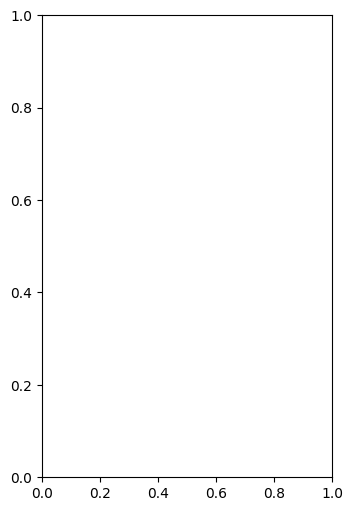

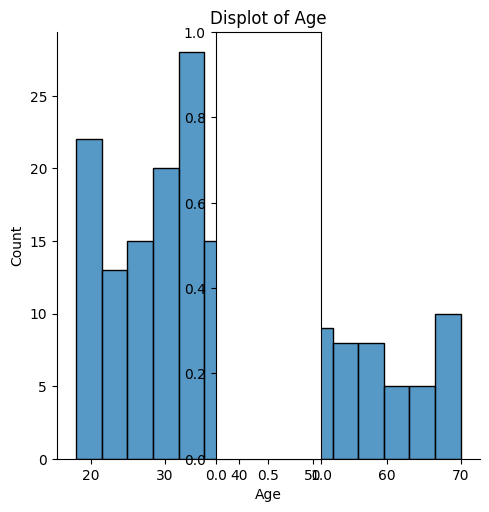

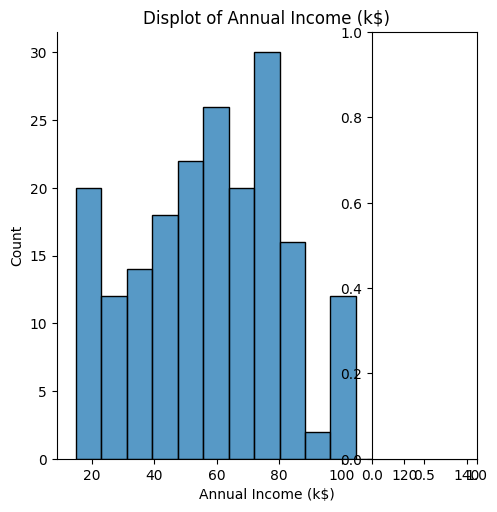

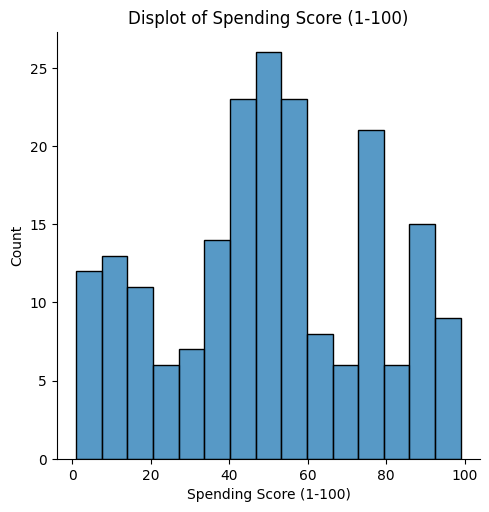

In [7]:
plt.figure(1,figsize=(15,6))
n = 1

for i in ['Age','Annual Income (k$)','Spending Score (1-100)']:
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace=.5,wspace=.5)
    sb.displot(df[i],bins=15)
    plt.title(f'Displot of {i}')
    n+=1

plt.show()

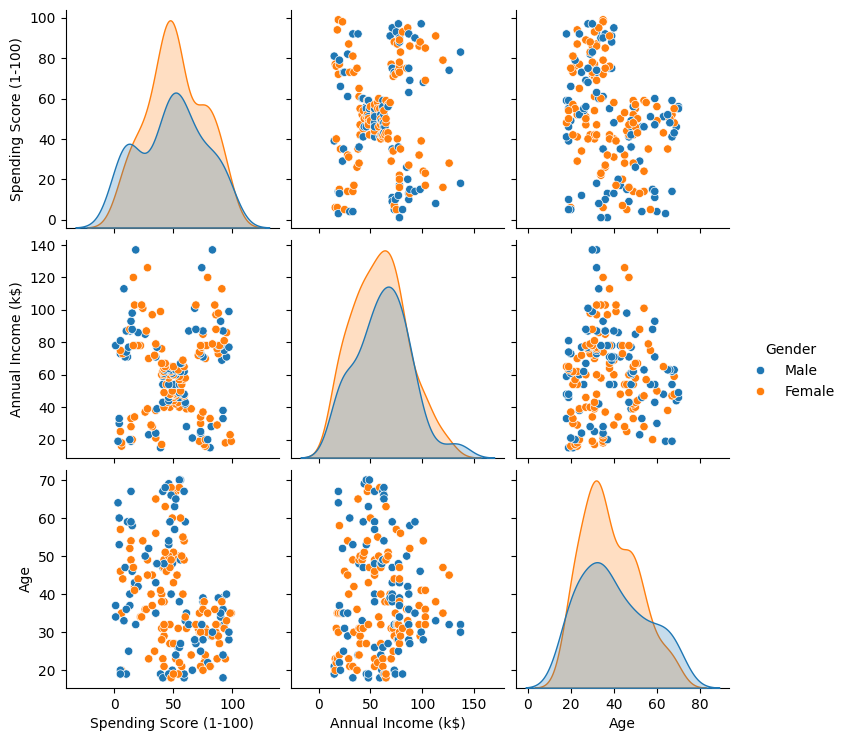

In [8]:
sb.pairplot(df,vars=['Spending Score (1-100)','Annual Income (k$)','Age'],hue='Gender')

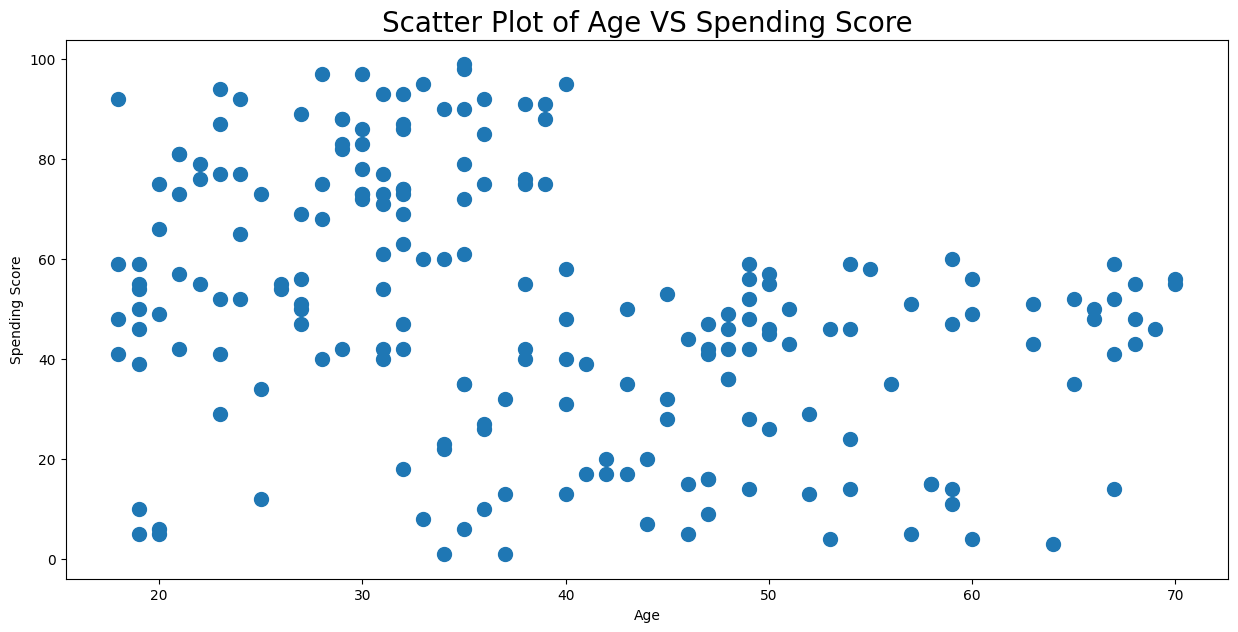

In [9]:
plt.figure(1,figsize=(15,7))
plt.title('Scatter Plot of Age VS Spending Score',fontsize=20)
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.scatter(x='Age',y='Spending Score (1-100)',data=df,s=100)
plt.show()

In [10]:
x1 = df[['Age','Spending Score (1-100)']].iloc[:,:].values
inertia = []

for n in range(1,15):
    algorithm = (KMeans(n_clusters=n,init='k-means++',n_init=10,max_iter=300,tol=.0001,random_state=11,algorithm='elkan'))
    algorithm.fit(x1)
    inertia.append(algorithm.inertia_)

inertia

[171535.5,
 75949.15601023017,
 45840.67661610868,
 28165.58356662934,
 23818.848251581338,
 19566.522341377604,
 15523.68401432875,
 13020.08451294822,
 11504.853626848193,
 10416.5953496966,
 9406.347094231307,
 8647.765171026458,
 7952.196409570821,
 7270.480484502168]

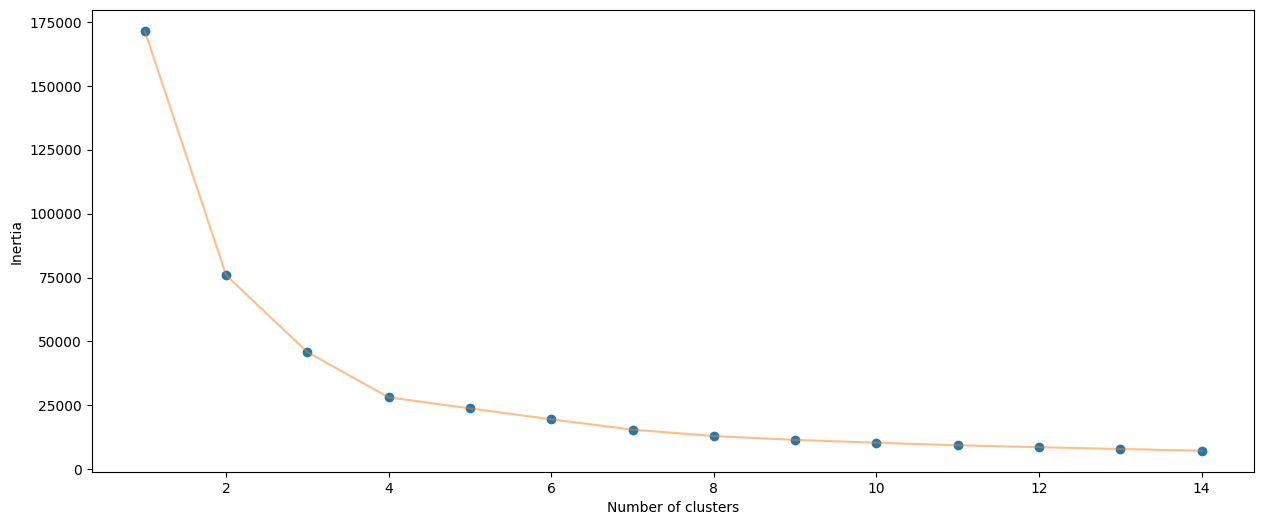

In [11]:
plt.figure(1,figsize=(15,6))
plt.plot(np.arange(1,15),inertia,'o')
plt.plot(np.arange(1,15),inertia,'-',alpha=.5)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [12]:
algorithm =(
    KMeans(
        n_clusters=4,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=.0001,
        random_state=111,
        algorithm='elkan'
    )
) 

algorithm.fit(x1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

In [13]:
h = .02
x_min,x_max = x1[:,0].min() - 1,x1[:,0].max() + 1
y_min,y_max = x1[:,1].min() - 1,x1[:,1].max() + 1

xx,yy = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
z = algorithm.predict(np.c_[xx.ravel(),yy.ravel()])
z

array([3, 3, 3, ..., 1, 1, 1], shape=(13500000,), dtype=int32)

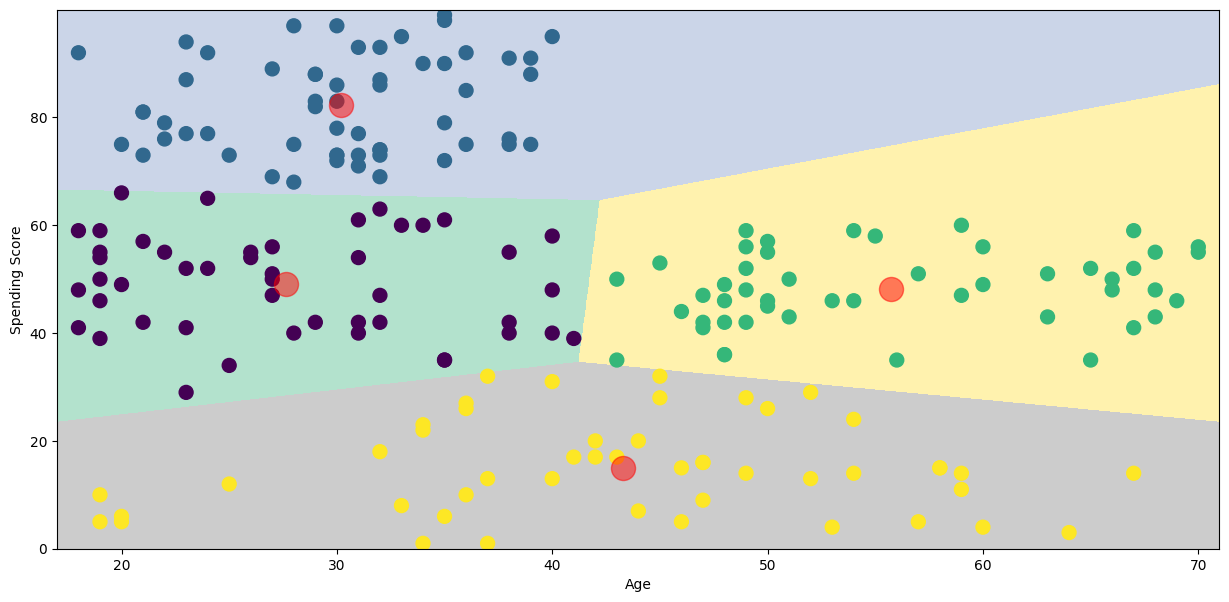

In [14]:
plt.figure(1,figsize=(15,7))
plt.clf()
z = z.reshape(xx.shape)
plt.imshow(z,
           interpolation='nearest',
           extent=(
               xx.min(),xx.max(),
               yy.min(),yy.max()
           ),
           cmap=plt.cm.Pastel2,
           aspect='auto',
           origin='lower'
)

plt.scatter(x=df['Age'],y=df['Spending Score (1-100)'],c = labels1,s=100)
plt.scatter(x=centroids1[:,0],y=centroids1[:,1],s=300,c='red',alpha=.5)
plt.ylabel('Spending Score')
plt.xlabel('Age')
plt.show()

In [15]:
x2 = df[['Annual Income (k$)','Spending Score (1-100)']].iloc[:,:].values
inertia = []

for n in range(1,11):
    algorithm = (KMeans(
        n_clusters=n,
        init='k-means++',
        max_iter=300,
        tol=.0001,
        random_state=111,
        algorithm='elkan'
    ))

    algorithm.fit(x2)
    inertia.append(algorithm.inertia_)

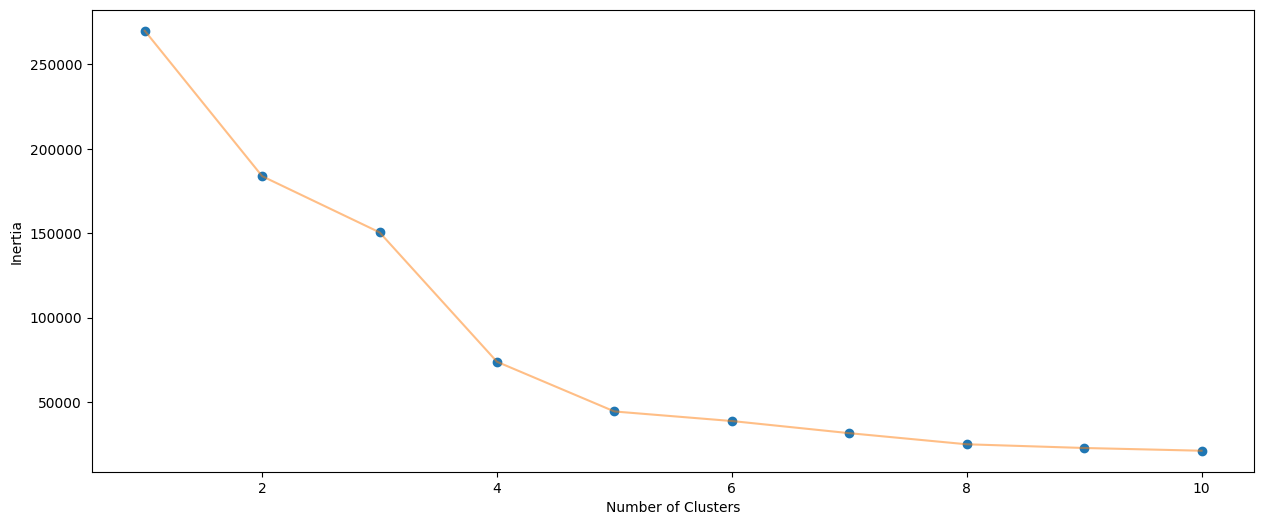

In [16]:
plt.figure(1,figsize=(15,6))
plt.plot(np.arange(1,11),inertia,'o')
plt.plot(np.arange(1,11),inertia,'-',alpha=.5)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [17]:
algorithm = (KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=.0001,
    random_state=111,
    algorithm='elkan'
))

algorithm.fit(x2)
labels2 = algorithm.labels_
centroids2 = algorithm.cluster_centers_

In [18]:
x_min,x_max = x2[:,0].min() - 1,x2[:,0].max() + 1
y_min,y_max = x2[:,1].min() - 1,x2[:,1].max() + 1
xx,yy  = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
z2 = algorithm.predict(np.c_[xx.ravel(),yy.ravel()])

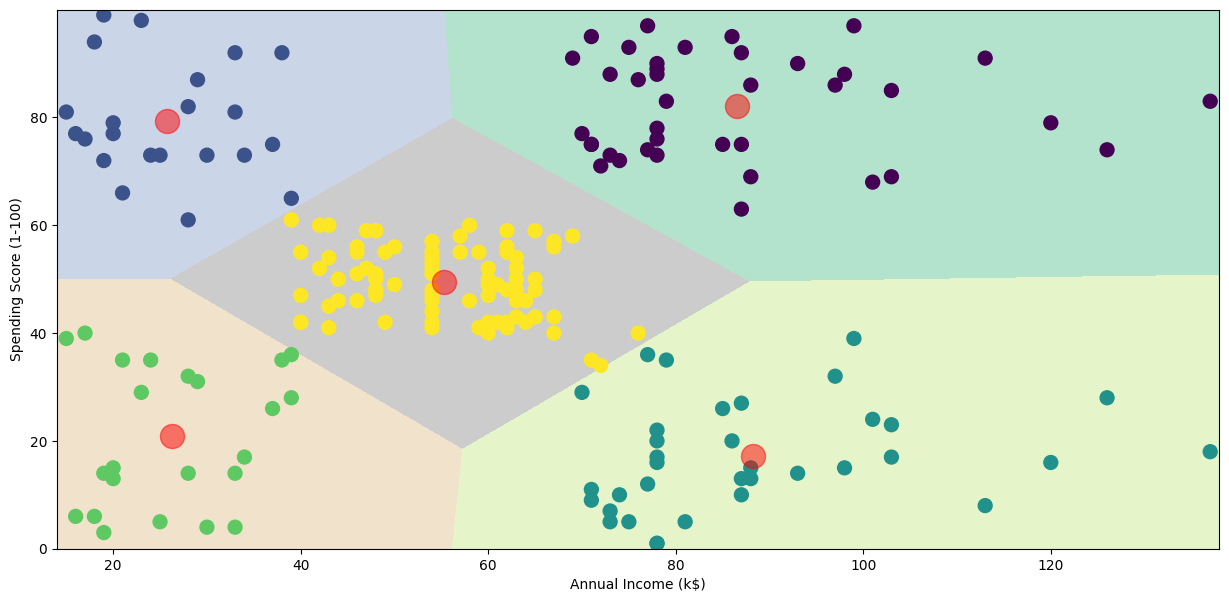

In [20]:
plt.figure(1,figsize=(15,7))
plt.clf()
z2 = z2.reshape(xx.shape)
plt.imshow(z2,
           interpolation='nearest',
           extent=(xx.min(),xx.max(),yy.min(),yy.max()),
           cmap=plt.cm.Pastel2,aspect='auto',origin='lower'
           )

plt.scatter(x='Annual Income (k$)',y='Spending Score (1-100)',data=df,c=labels2,s=100)
plt.scatter(x=centroids2[:,0],y=centroids2[:,1],s=300,c='red',alpha=.5)
plt.ylabel('Spending Score (1-100)')
plt.xlabel('Annual Income (k$)')
plt.show()

In [22]:
x3 = df[['Age','Annual Income (k$)','Spending Score (1-100)']].iloc[:,:].values
inertia  = []

for n in range(1,11):
    algorithm = (KMeans(
        n_clusters=n,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=.0001,
        random_state=111,
        algorithm='elkan'
    ))

    algorithm.fit(x3)
    inertia.append(algorithm.inertia_)

inertia

[308812.77999999997,
 212840.16982097185,
 143342.75157170603,
 104366.15145556197,
 75479.76429338777,
 58300.44332159069,
 51525.77377037377,
 44307.87341670446,
 40932.6282276547,
 37639.71767150413]

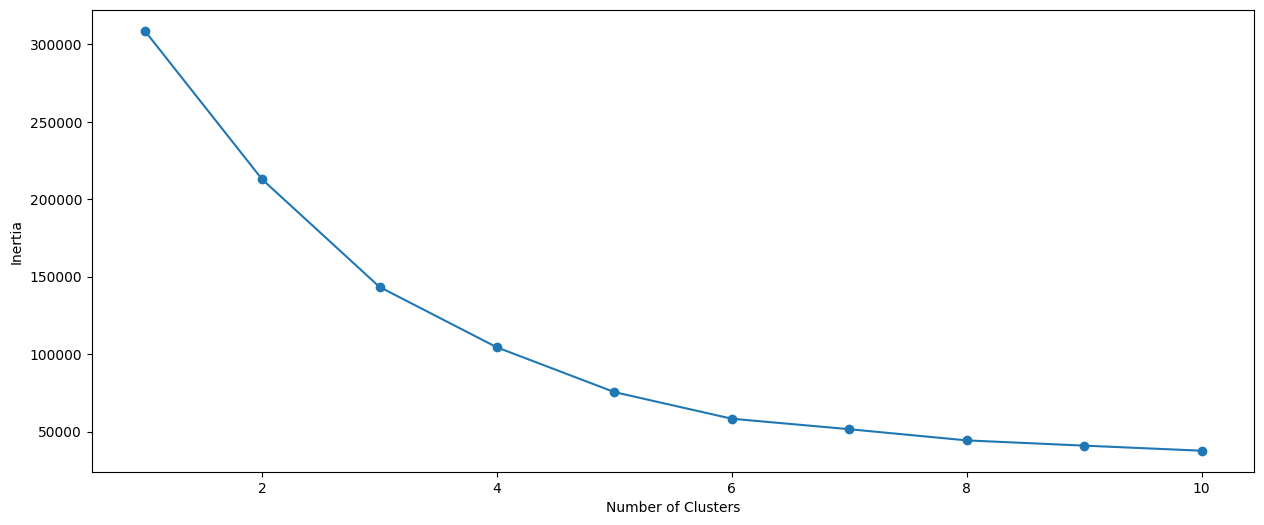

In [25]:
plt.figure(1,figsize=(15,6))
plt.plot(np.arange(1,11),inertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [27]:
algorithm = (KMeans(
    n_clusters=6,
    n_init=10,
    max_iter=300,
    tol=.0001,
    random_state=111,
    algorithm='elkan'
))

algorithm.fit(x3)
labels3 = algorithm.labels_
centroids3 = algorithm.cluster_centers_

y_kmeans = algorithm.fit_predict(x3)
df['cluster'] = pd.DataFrame(y_kmeans)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
CustomerID,,,,,
1,Male,19,15,39,5.0
2,Male,21,15,81,4.0
3,Female,20,16,6,5.0
4,Female,23,16,77,4.0
5,Female,31,17,40,5.0


In [28]:
import plotly as py
import plotly.graph_objs as go

trace1 = go.Scatter3d(
    x = df['Age'],
    y = df['Spending Score (1-100)'],
    z = df['Annual Income (k$)'],
    mode='markers',
        marker=dict(
            color = df['cluster'],
            size=10,
            line = dict(
                color=df['cluster'],
                width=12
            ),
            opacity=.8
        )
)

data = [trace1]

layout = go.Layout(
    title='Clusters wrt Age, Income and Spending Scores',
    scene=dict(
        xaxis = dict(title='Age'),
        yaxis = dict(title='Spending Score'),
        zaxis = dict(title='Annual Income')
    )
)

fig = go.Figure(data=data,layout=layout)
py.offline.iplot(fig)

In [29]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
CustomerID,,,,,
1,Male,19,15,39,5.0
2,Male,21,15,81,4.0
3,Female,20,16,6,5.0
4,Female,23,16,77,4.0
5,Female,31,17,40,5.0
